In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Walmart.csv")

In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
print("Rows and Columns:", df.shape)

Rows and Columns: (6435, 8)


In [7]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [11]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Week"] = df["Date"].dt.isocalendar().week

In [12]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5,9


In [13]:
df.to_csv("Walmart_Cleaned.csv", index=False)

In [14]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,Week
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.0
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,6.447552,15.678322,25.818182
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.000000,1.0
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,4.000000,8.000000,14.0
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,6.000000,16.000000,26.0
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,9.000000,23.000000,38.0
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000,31.000000,52.0
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,3.238308,8.755780,14.129201


In [15]:
print("Number of Stores:", df["Store"].nunique())

Number of Stores: 45


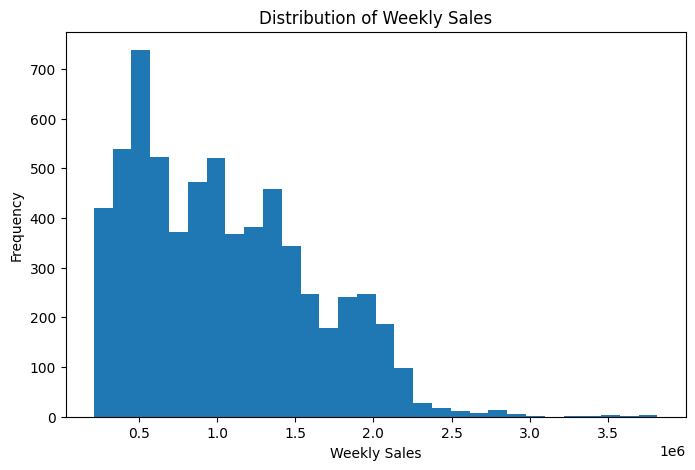

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Weekly_Sales"], bins=30)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

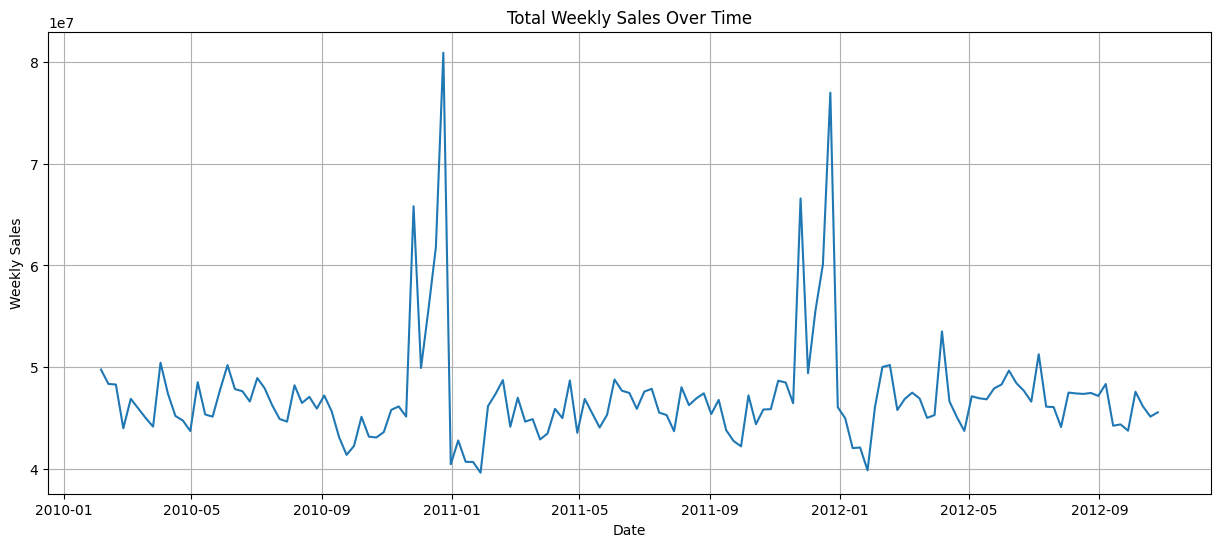

In [17]:
sales_trend = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(15,6))
plt.plot(sales_trend)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.grid(True)
plt.show()

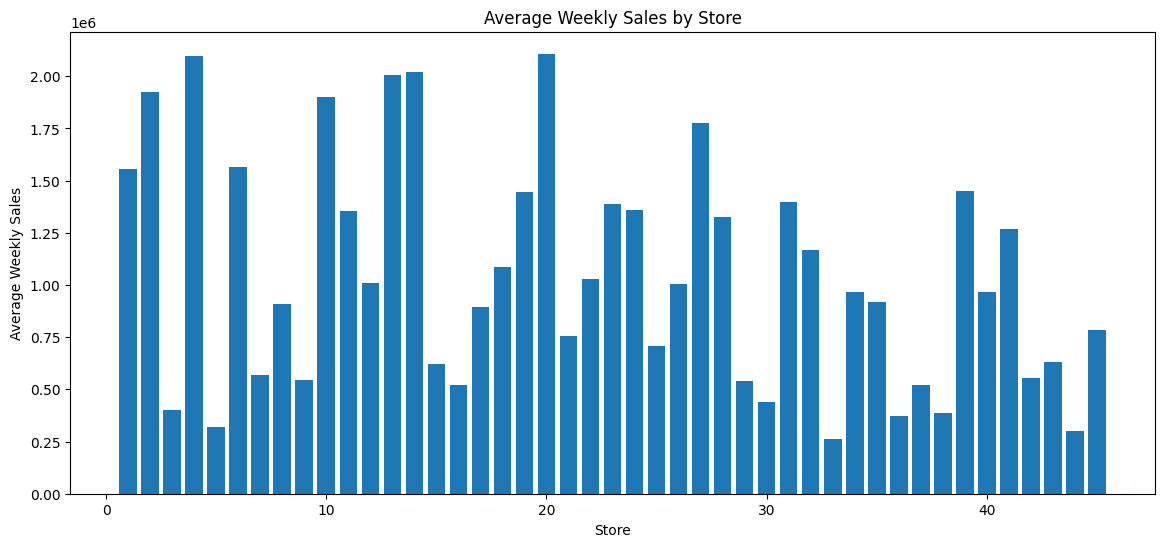

In [18]:
store_sales = df.groupby("Store")["Weekly_Sales"].mean()

plt.figure(figsize=(14,6))
plt.bar(store_sales.index, store_sales.values)
plt.title("Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.show()

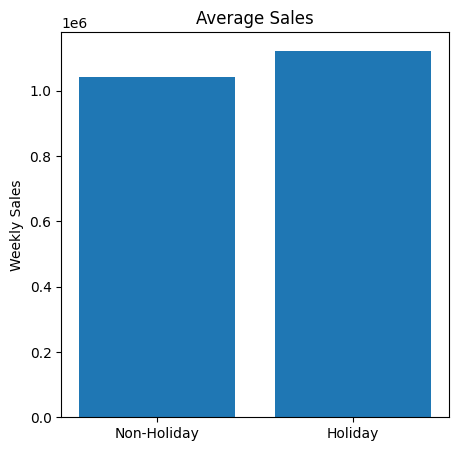

In [19]:
holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

plt.figure(figsize=(5,5))
plt.bar(["Non-Holiday","Holiday"], holiday_sales.values)
plt.title("Average Sales")
plt.ylabel("Weekly Sales")
plt.show()

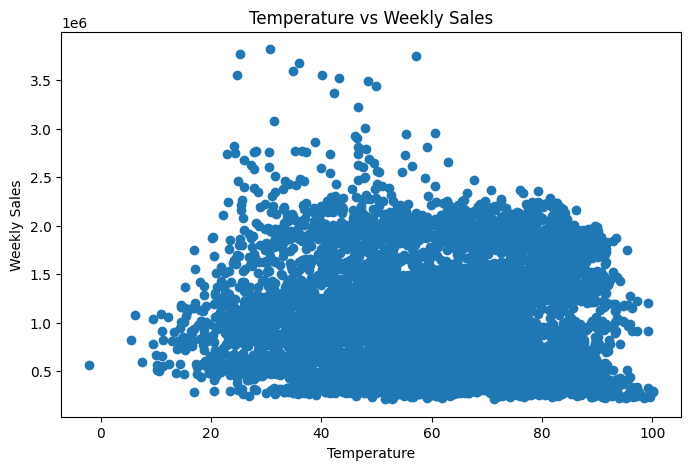

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df["Temperature"], df["Weekly_Sales"])
plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()

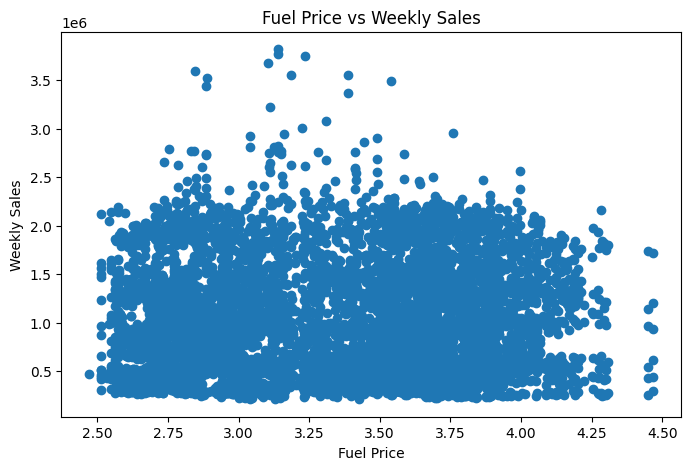

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df["Fuel_Price"], df["Weekly_Sales"])
plt.title("Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.show()

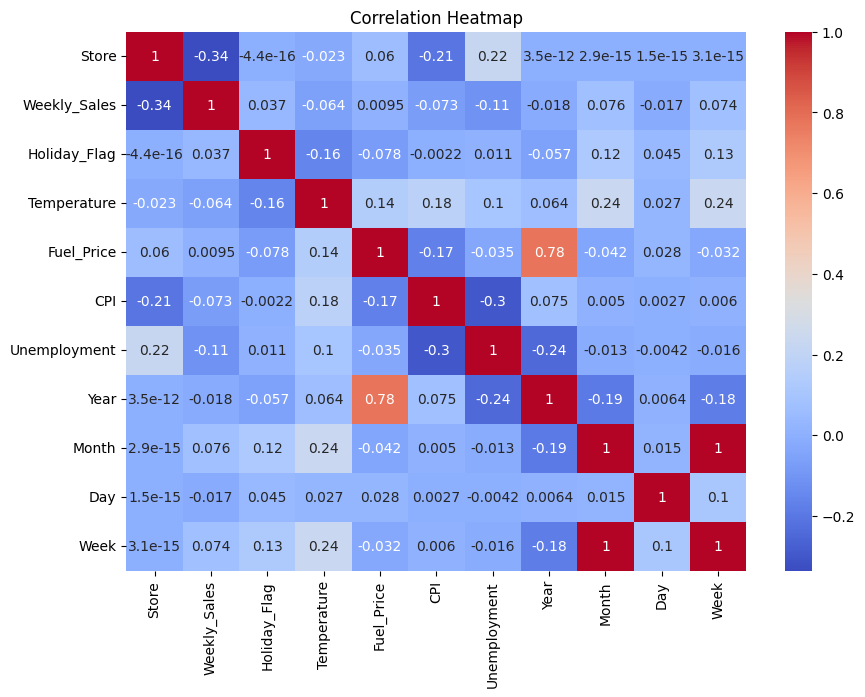

In [22]:
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

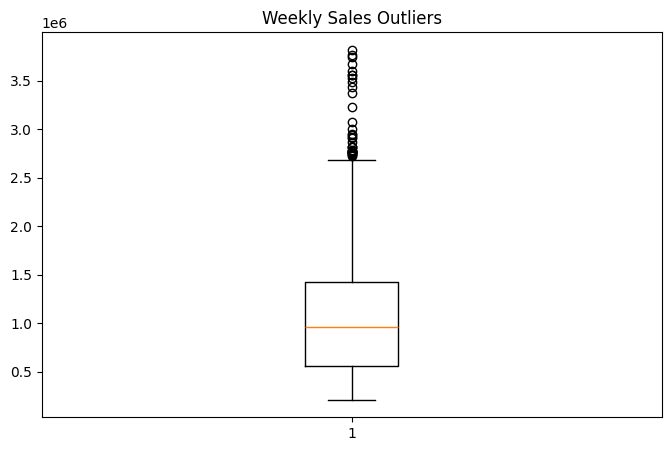

In [23]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Weekly_Sales"])
plt.title("Weekly Sales Outliers")
plt.show()

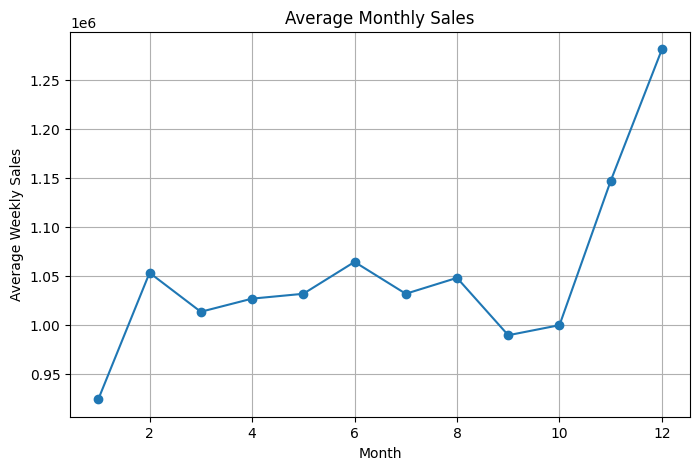

In [24]:
monthly_sales = df.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.grid(True)
plt.show()

In [25]:
df["Quarter"] = df["Date"].dt.quarter

In [26]:
df["DayOfWeek"] = df["Date"].dt.day_name()

In [27]:
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

In [28]:
df["Month_Name"] = df["Date"].dt.month_name()

In [29]:
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)

In [30]:
df = df.sort_values(by=["Store", "Date"])

In [31]:
df["Lag_1"] = df.groupby("Store")["Weekly_Sales"].shift(1)

In [32]:
df["Rolling_Mean_4"] = (
    df.groupby("Store")["Weekly_Sales"]
      .rolling(window=4)
      .mean()
      .reset_index(level=0, drop=True)
)

In [33]:
df["Rolling_STD_4"] = (
    df.groupby("Store")["Weekly_Sales"]
      .rolling(window=4)
      .std()
      .reset_index(level=0, drop=True)
)

In [34]:
print(df.isnull().sum())

Store               0
Date                0
Weekly_Sales        0
Holiday_Flag        0
Temperature         0
Fuel_Price          0
CPI                 0
Unemployment        0
Year                0
Month               0
Day                 0
Week                0
Quarter             0
DayOfWeek           0
WeekOfYear          0
Month_Name          0
Year_Month          0
Lag_1              45
Rolling_Mean_4    135
Rolling_STD_4     135
dtype: int64


In [35]:
df = df.dropna().reset_index(drop=True)

In [36]:
df.to_csv("Walmart_Featured.csv", index=False)

In [37]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,Week,Quarter,DayOfWeek,WeekOfYear,Month_Name,Year_Month,Lag_1,Rolling_Mean_4,Rolling_STD_4
0,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26,8,1,Friday,8,February,2010-02,1611968.17,1.576836e+06,112353.415114
1,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5,9,1,Friday,9,March,2010-03,1409727.59,1.554615e+06,103135.002548
2,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,12,10,1,Friday,10,March,2010-03,1554806.68,1.504011e+06,95360.050839
3,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,19,11,1,Friday,11,March,2010-03,1439541.59,1.469148e+06,62599.457150
4,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,26,12,1,Friday,12,March,2010-03,1472515.79,1.467823e+06,64308.381016


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [39]:
sales = df.groupby("Date")["Weekly_Sales"].sum()

sales.head()

Date
2010-02-26    43968571.13
2010-03-05    46871470.30
2010-03-12    45925396.51
2010-03-19    44988974.64
2010-03-26    44133961.05
Name: Weekly_Sales, dtype: float64

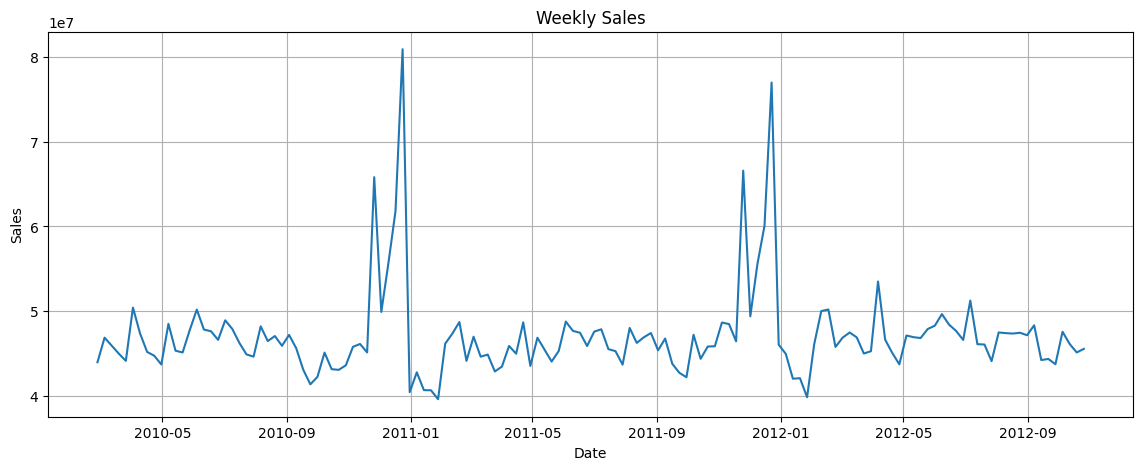

In [40]:
plt.figure(figsize=(14,5))
plt.plot(sales)
plt.title("Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [41]:
train_size = int(len(sales) * 0.8)

train = sales[:train_size]
test = sales[train_size:]

print(len(train))
print(len(test))

112
28


In [42]:
model = ARIMA(train, order=(5,1,0))

model_fit = model.fit()

C:\Users\hp\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [43]:
forecast = model_fit.forecast(steps=len(test))

In [44]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 1517284.7779987815
RMSE: 1988366.570863372


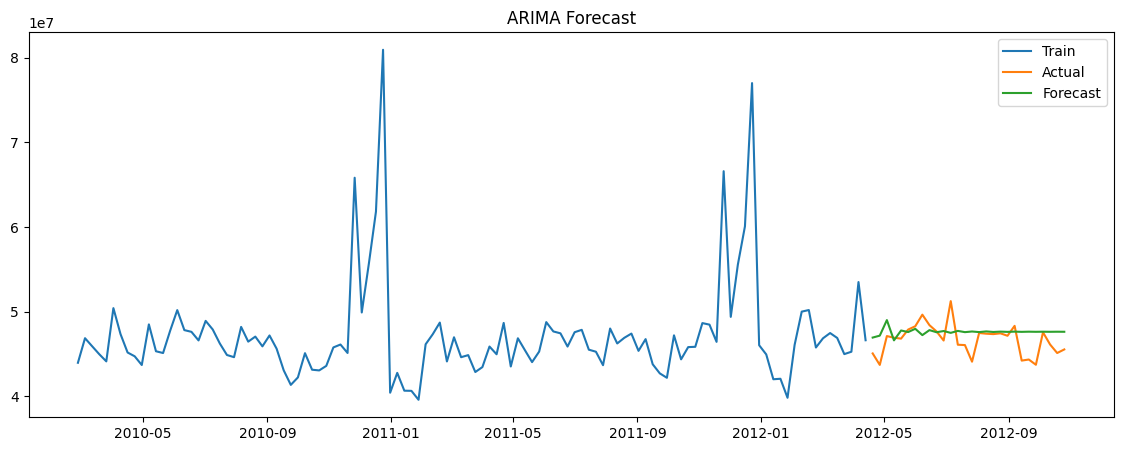

In [45]:
plt.figure(figsize=(14,5))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Actual")

plt.plot(test.index, forecast, label="Forecast")

plt.legend()

plt.title("ARIMA Forecast")

plt.show()

In [46]:
future_forecast = model_fit.forecast(steps=12)

print(future_forecast)

2012-04-20    4.694604e+07
2012-04-27    4.717365e+07
2012-05-04    4.900926e+07
2012-05-11    4.661770e+07
2012-05-18    4.778252e+07
2012-05-25    4.759900e+07
2012-06-01    4.798086e+07
2012-06-08    4.723529e+07
2012-06-15    4.782596e+07
2012-06-22    4.757671e+07
2012-06-29    4.771756e+07
2012-07-06    4.750267e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


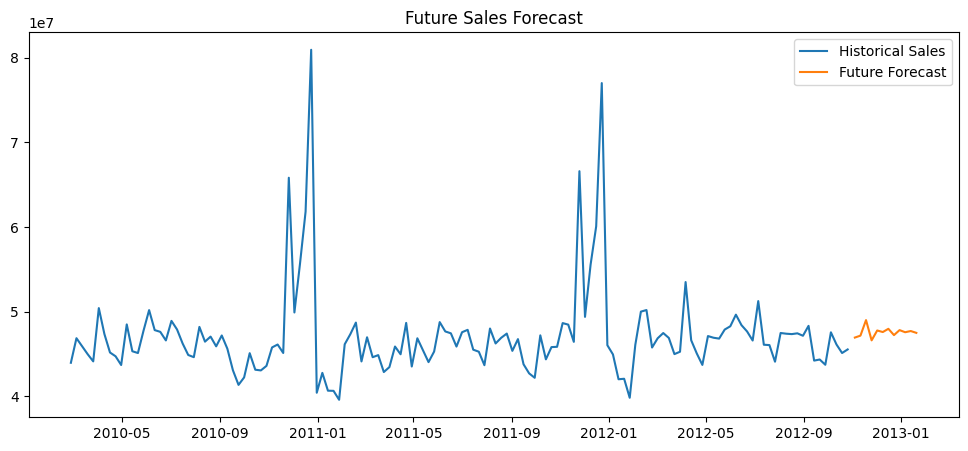

In [47]:
plt.figure(figsize=(12,5))

plt.plot(sales, label="Historical Sales")

future_dates = pd.date_range(
    start=sales.index[-1] + pd.Timedelta(days=7),
    periods=12,
    freq="W"
)

plt.plot(future_dates, future_forecast, label="Future Forecast")

plt.legend()

plt.title("Future Sales Forecast")

plt.show()

In [48]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

ADF Statistic: -5.848550176873287
p-value: 3.6348100943188355e-07
The time series is stationary.


In [49]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(0,0,0,0)
)

sarima_fit = sarima_model.fit(disp=False)

C:\Users\hp\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [50]:
sarima_forecast = sarima_fit.forecast(steps=len(test))

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, sarima_forecast)
rmse = np.sqrt(mean_squared_error(test, sarima_forecast))

print("SARIMA MAE :", mae)
print("SARIMA RMSE:", rmse)

SARIMA MAE : 1497570.5449549065
SARIMA RMSE: 1972953.376240306


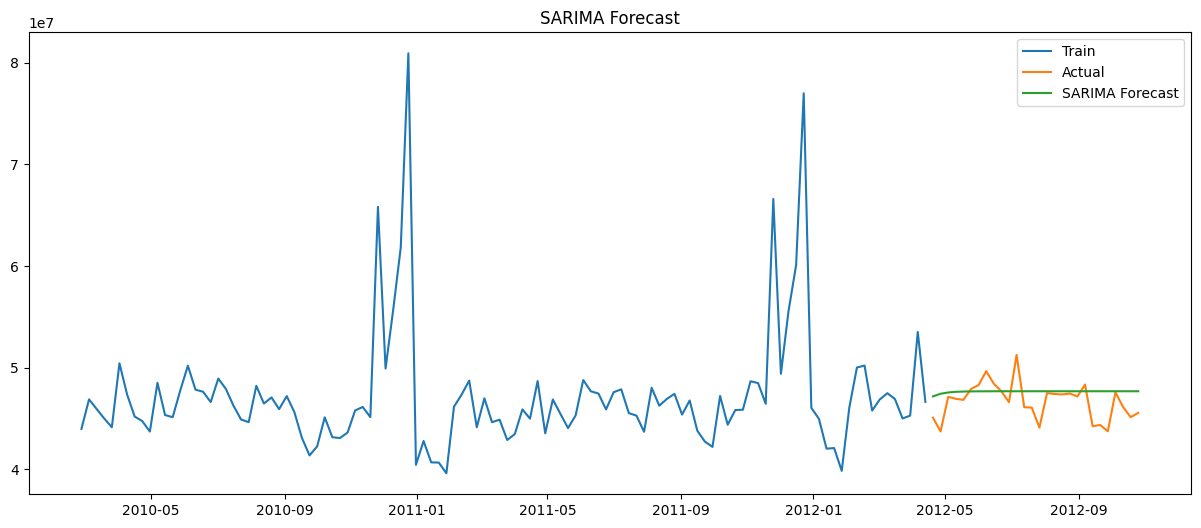

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Actual")

plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

In [56]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [57]:
prophet_df = sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2010-02-26,43968571.13
1,2010-03-05,46871470.30
2,2010-03-12,45925396.51
3,2010-03-19,44988974.64
4,2010-03-26,44133961.05


In [58]:
train_size = int(len(prophet_df) * 0.8)

train = prophet_df[:train_size]
test = prophet_df[train_size:]

In [59]:
model = Prophet()

model.fit(train)

10:23:51 - cmdstanpy - INFO - Chain [1] start processing
10:23:54 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
future = model.make_future_dataframe(periods=len(test), freq='W')

forecast = model.predict(future)

In [61]:
pred = forecast["yhat"][-len(test):].values

In [66]:
prophet_mae = mean_absolute_error(test["y"], pred)

prophet_rmse = np.sqrt(mean_squared_error(test["y"], pred))

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 1227398.5552471387
Prophet RMSE: 1574585.4050228202


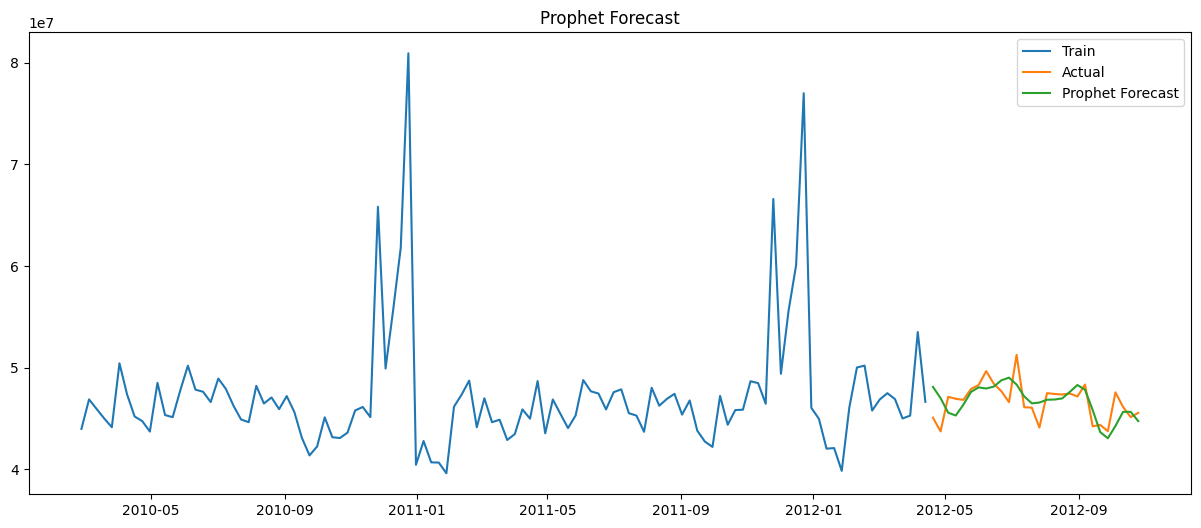

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(train["ds"], train["y"], label="Train")

plt.plot(test["ds"], test["y"], label="Actual")

plt.plot(test["ds"], pred, label="Prophet Forecast")

plt.legend()

plt.title("Prophet Forecast")

plt.show()

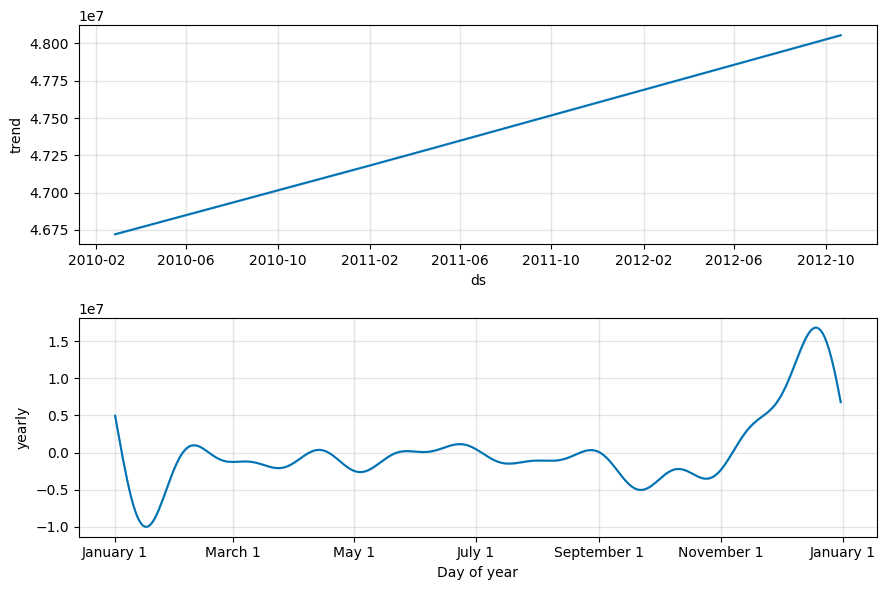

In [68]:
model.plot_components(forecast)
plt.show()

In [69]:
comparison = {
    "Model": ["ARIMA", "SARIMA", "Prophet"],
    "MAE": [
        1517284.78,
        1497570.54,
        prophet_mae
    ],
    "RMSE": [
        1988366.57,
        1972953.38,
        prophet_rmse
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,MAE,RMSE
0,ARIMA,1.517285e+06,1.988367e+06
1,SARIMA,1.497571e+06,1.972953e+06
2,Prophet,1.227399e+06,1.574585e+06


In [70]:
import joblib

joblib.dump(model, "prophet_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
